# Crypto Futures Simulation & Risk Analysis

#### Project Overview:
This project simulates leveraged crypto futures trading for multiple coins and customers. It evaluates the impact of leverage and stop-loss strategies on both customer equity and exchange profit. Key risk metrics such as maximum drawdown, volatility, and Sharpe ratio are also calculated to provide a quantitative view of potential risks.

You can find the data used in this project on Kaggle:
https://www.kaggle.com/datasets/sudalairajkumar/cryptocurrencypricehistory

## Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Function to read and clean cryptocurrency CSV data
def read_data(file_path):
    """
    Read cryptocurrency CSV data and perform basic cleaning:
    - Convert 'date' column to datetime
    - Sort data by date
    - Drop missing values
    - Reset index
    """
    data = pd.read_csv(file_path)
    
    # Convert 'date' to datetime
    data['date'] = pd.to_datetime(data['date'])
    
    # Sort by date
    data = data.sort_values('date')
    
    # Drop missing values
    data = data.dropna()
    
    # Reset index
    data = data.reset_index(drop=True)
    
    return data

In [3]:
# Read BTC, ETH, BNB datasets
bitcoin = read_data("bitcoin.csv")
eth = read_data("ethereum.csv")
binancecoin = read_data("binancecoin.csv")

In [4]:
# Display first few rows to check
print(bitcoin.head())
print("-----------------------------------------------------------")
print(eth.head())
print("-----------------------------------------------------------")
print(binancecoin.head())

        date    price  total_volume    market_cap coin_name
0 2015-01-01  313.992  4.699936e+07  4.293958e+09   bitcoin
1 2015-01-02  314.446  3.885591e+07  4.301448e+09   bitcoin
2 2015-01-03  286.572  1.187789e+08  3.921358e+09   bitcoin
3 2015-01-04  260.936  2.055001e+08  3.571640e+09   bitcoin
4 2015-01-05  273.220  1.550381e+08  3.740880e+09   bitcoin
-----------------------------------------------------------
        date     price  total_volume    market_cap coin_name
0 2015-08-07  2.831620  9.062200e+04  0.000000e+00  ethereum
1 2015-08-08  1.330750  3.680700e+05  8.033948e+07  ethereum
2 2015-08-10  0.687586  4.004641e+05  4.155631e+07  ethereum
3 2015-08-11  1.067379  1.518998e+06  6.453901e+07  ethereum
4 2015-08-12  1.256613  2.073893e+06  7.601326e+07  ethereum
-----------------------------------------------------------
        date     price  total_volume    market_cap    coin_name
0 2017-09-16  0.107251      1.051223  1.072506e+07  binancecoin
1 2017-09-17  0.154041    

## Major Cryptocurrency Price Trends

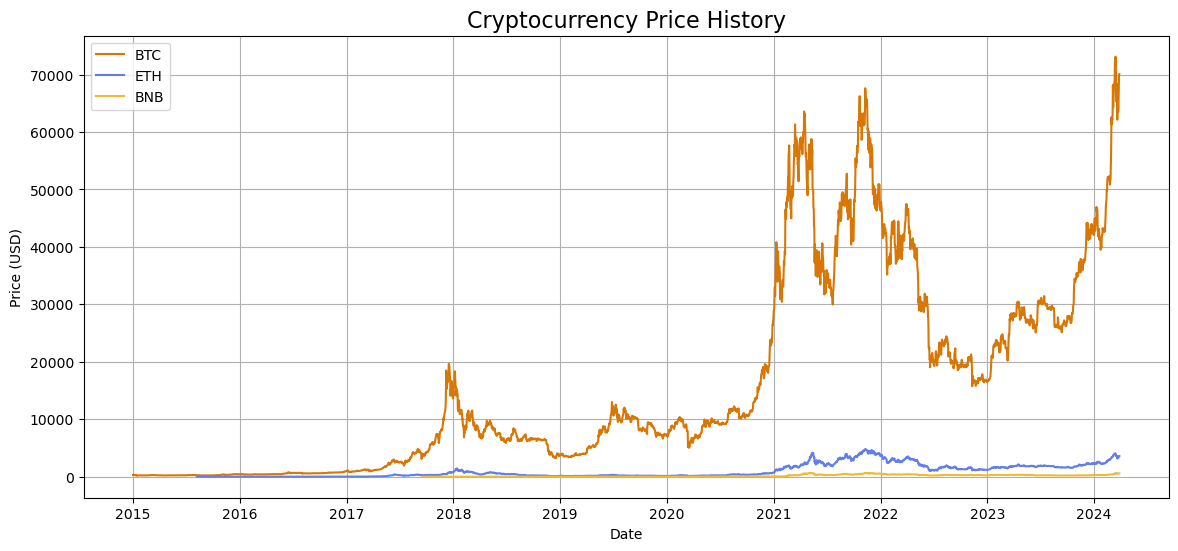

In [5]:
# Plot price history for BTC, ETH, BNB
plt.figure(figsize=(14,6))

# plot BTC 
plt.plot(bitcoin['date'], bitcoin['price'], label='BTC', color='#d97706')

# plot ETH
plt.plot(eth['date'], eth['price'], label='ETH', color='#627eea')

# plot BNB
plt.plot(binancecoin['date'], binancecoin['price'], label='BNB', color='#f3ba2f')

# Add title and labels
plt.title('Cryptocurrency Price History', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

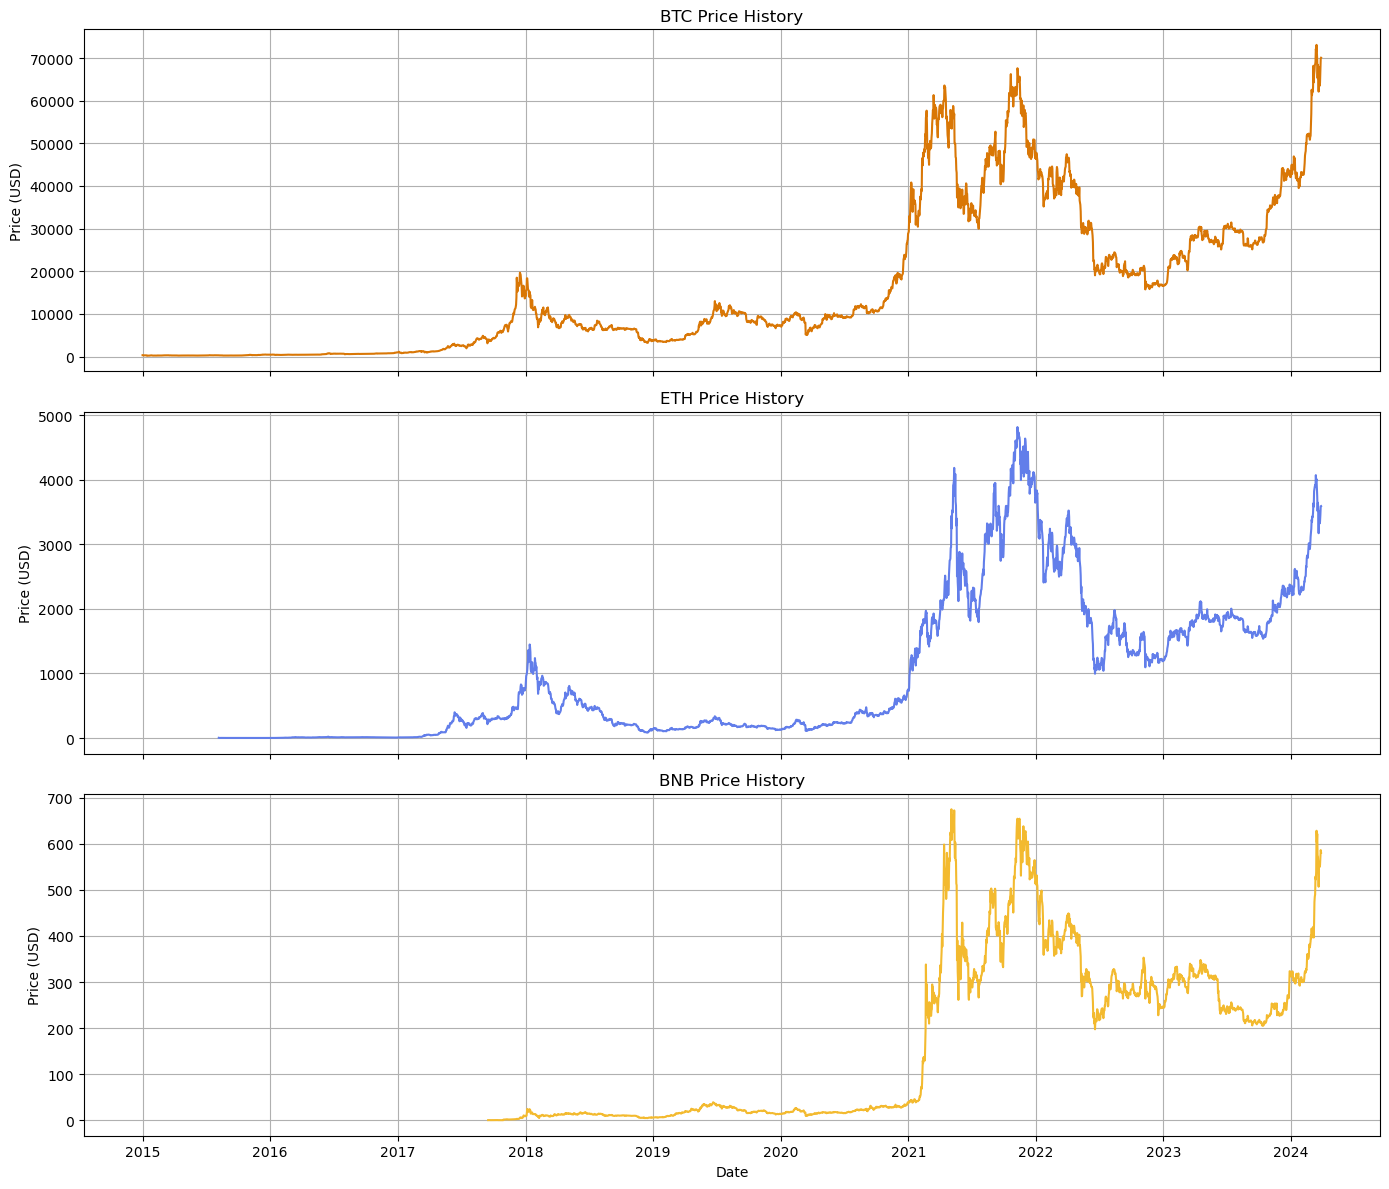

In [6]:
# Create a figure with 3 subplots (one row per coin)
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ---------------- BTC ----------------
axes[0].plot(bitcoin['date'], bitcoin['price'], color='#d97706')
axes[0].set_title('BTC Price History')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True)

# ---------------- ETH ----------------
axes[1].plot(eth['date'], eth['price'], color='#627eea')
axes[1].set_title('ETH Price History')
axes[1].set_ylabel('Price (USD)')
axes[1].grid(True)

# ---------------- BNB ----------------
axes[2].plot(binancecoin['date'], binancecoin['price'], color='#f3ba2f')
axes[2].set_title('BNB Price History')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price (USD)')
axes[2].grid(True)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

In [7]:
# Step 1: Calculate daily return
#bitcoin['return'] = bitcoin['price'].pct_change().fillna(0)
#print(bitcoin[['date', 'price', 'return']].head(10))

In [8]:
#bitcoin_2024 = bitcoin[bitcoin['date'].dt.year == 2024].reset_index(drop=True)  # filter only 2024

In [9]:
# ------------------------------
# Step 3: Inspect the first 10 rows
# ------------------------------
#print(bitcoin_2024[['date', 'price', 'return']].head(10))

## Historic Return Analysis

In [10]:
# ------------------------------
# Compute daily return on original datasets
# ------------------------------
bitcoin['return'] = bitcoin['price'].pct_change()
eth['return'] = eth['price'].pct_change()
binancecoin['return'] = binancecoin['price'].pct_change()

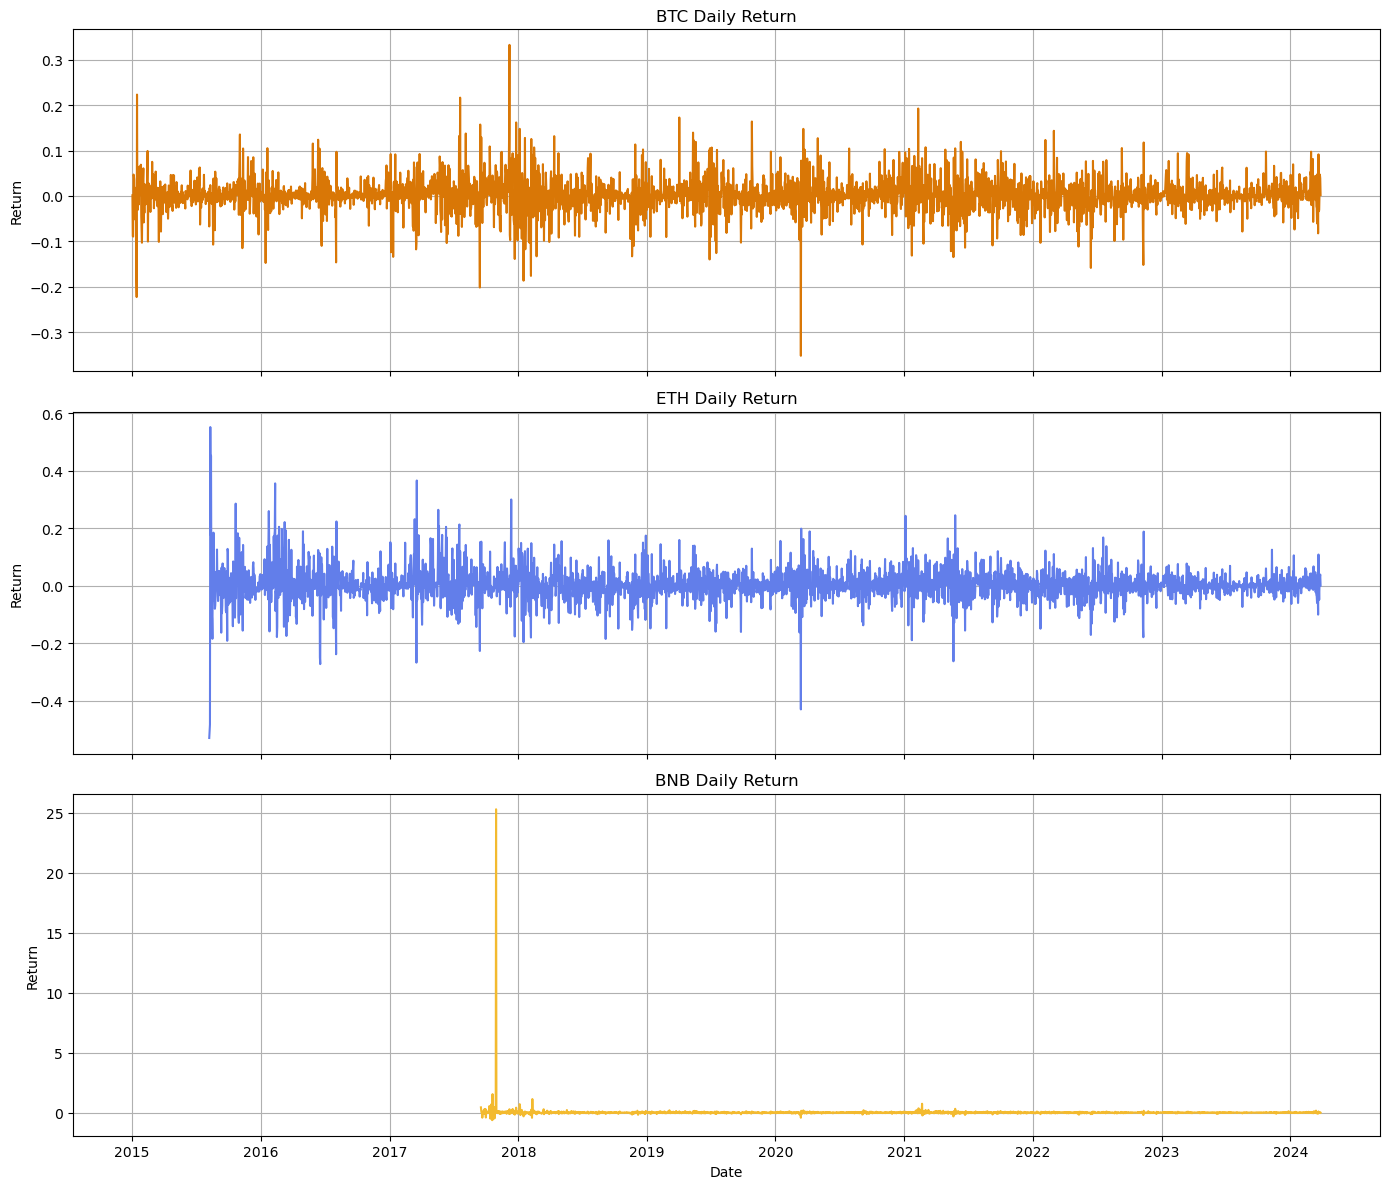

In [11]:
# ------------------------------
# Visualize daily returns for all coins
# ------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ---------------- BTC Return ----------------
axes[0].plot(bitcoin['date'], bitcoin['return'], color='#d97706')
axes[0].set_title('BTC Daily Return')
axes[0].set_ylabel('Return')
axes[0].grid(True)

# ---------------- ETH Return ----------------
axes[1].plot(eth['date'], eth['return'], color='#627eea')
axes[1].set_title('ETH Daily Return')
axes[1].set_ylabel('Return')
axes[1].grid(True)

# ---------------- BNB Return ----------------
axes[2].plot(binancecoin['date'], binancecoin['return'], color='#f3ba2f')
axes[2].set_title('BNB Daily Return')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Return')
axes[2].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

## Single-Coin Futures Simulation

The goal of this simulation is to understand the behavior of leveraged futures trading on three major cryptocurrencies: Bitcoin (BTC), Ethereum (ETH), and Binance Coin (BNB). By applying different leverage levels (5× and 10×), we aim to:

Assess the impact of leverage on customer equity:
Higher leverage amplifies both gains and losses, helping us visualize how quickly positions can grow or be liquidated.

Compare risk across assets:
BTC, ETH, and BNB have different price volatilities and liquidity, which affects how leveraged positions perform.
Evaluate platform exposure – Understanding liquidation events and potential fees helps quantify the exchange’s profit under different leverage scenarios.

Provide insights for risk management:
Simulations allow us to see the effect of leverage on equity drawdowns and help inform position sizing, stop-loss rules, and margin requirements.

By focusing on 2024 data, we capture the most recent market dynamics, ensuring the simulation reflects current volatility and trading conditions.

In [12]:
# Filter 2024 only and compute daily returns (keep original data intact)
# ------------------------------

def prepare_2024(df):
    df_2024 = df[df['date'].dt.year == 2024].reset_index(drop=True)
    return df_2024

bitcoin_2024 = prepare_2024(bitcoin)
eth_2024 = prepare_2024(eth)
binancecoin_2024 = prepare_2024(binancecoin)

# Align dates across coins
dates = bitcoin_2024['date']
eth_2024 = eth_2024[eth_2024['date'].isin(dates)].reset_index(drop=True)
binancecoin_2024 = binancecoin_2024[binancecoin_2024['date'].isin(dates)].reset_index(drop=True)

In [13]:
# ------------------------------
# Define a function to simulate equity for single coin
# ------------------------------
def simulate_single_coin(data, initial_equity, leverage, maintenance_margin_ratio=0.05):
    equity = [initial_equity]
    liquidation = [False]
    
    for i in range(1, len(data)):
        daily_return = data['return'].iloc[i]
        position = equity[-1] * leverage
        pnl = position * daily_return
        new_equity = equity[-1] + pnl
        maintenance_margin = position * maintenance_margin_ratio
        
        if new_equity < maintenance_margin:
            liquidation.append(True)
            new_equity = 0
        else:
            liquidation.append(False)
        
        equity.append(new_equity)
    
    return equity, liquidation

In [14]:
# ---------------- BTC ----------------
btc_eq_5x, btc_liq_5x = simulate_single_coin(bitcoin_2024, 10000, 5)
btc_eq_10x, btc_liq_10x = simulate_single_coin(bitcoin_2024, 10000, 10)

bitcoin_2024['equity_5x'] = btc_eq_5x
bitcoin_2024['liq_5x'] = btc_liq_5x
bitcoin_2024['equity_10x'] = btc_eq_10x
bitcoin_2024['liq_10x'] = btc_liq_10x


# ---------------- ETH ----------------
eth_eq_5x, eth_liq_5x = simulate_single_coin(eth_2024, 10000, 5)
eth_eq_10x, eth_liq_10x = simulate_single_coin(eth_2024, 10000, 10)

eth_2024['equity_5x'] = eth_eq_5x
eth_2024['liq_5x'] = eth_liq_5x
eth_2024['equity_10x'] = eth_eq_10x
eth_2024['liq_10x'] = eth_liq_10x


# ---------------- BNB ----------------
bnb_eq_5x, bnb_liq_5x = simulate_single_coin(binancecoin_2024, 10000, 5)
bnb_eq_10x, bnb_liq_10x = simulate_single_coin(binancecoin_2024, 10000, 10)

binancecoin_2024['equity_5x'] = bnb_eq_5x
binancecoin_2024['liq_5x'] = bnb_liq_5x
binancecoin_2024['equity_10x'] = bnb_eq_10x
binancecoin_2024['liq_10x'] = bnb_liq_10x

In [15]:
def plot_single_coin_equity(df, coin_name, leverages=[5, 10]):
    """
    Plot price + equity + liquidation for a single coin
    
    Parameters:
    df : DataFrame containing date, price, equity_<lev>x, liq_<lev>x
    coin_name : str, e.g. 'BTC'
    leverages : list of leverage values, e.g. [5, 10]
    """
    
    fig, axes = plt.subplots(len(leverages), 1, figsize=(14, 5*len(leverages)), sharex=True)
    
    # If only one leverage, make axes iterable
    if len(leverages) == 1:
        axes = [axes]
    
    for i, lev in enumerate(leverages):
        # Price
        colors = {5: '#5b21b6',  10: '#dc2626'  }
        axes[i].plot(df['date'], df['price'], label=f'{coin_name} Price', color='#6b7280')   
        
        # Equity 
        axes[i].plot(df['date'], df[f'equity_{lev}x'], label=f'Customer Equity ({lev}x)', color=colors[lev])
        axes[i].set_title(f'{coin_name} Futures Customer Equity ({lev}x leverage, 2024)')
        axes[i].set_ylabel('Price / Equity (USD)')
        axes[i].legend()
        axes[i].grid(True)
    
    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

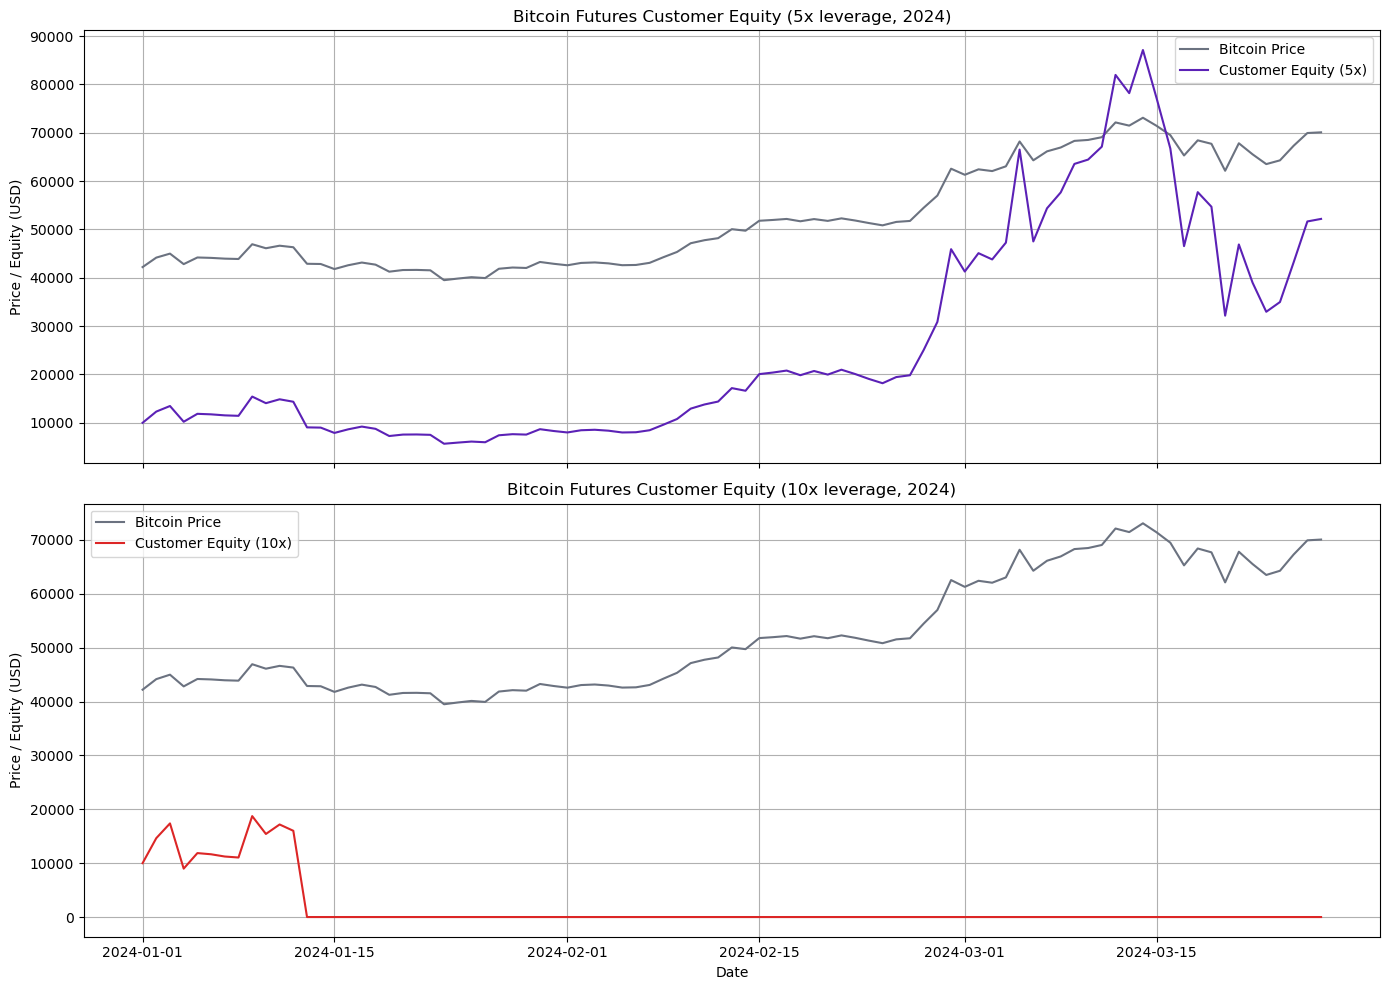

In [16]:
plot_single_coin_equity(bitcoin_2024, "Bitcoin", leverages=[5, 10])

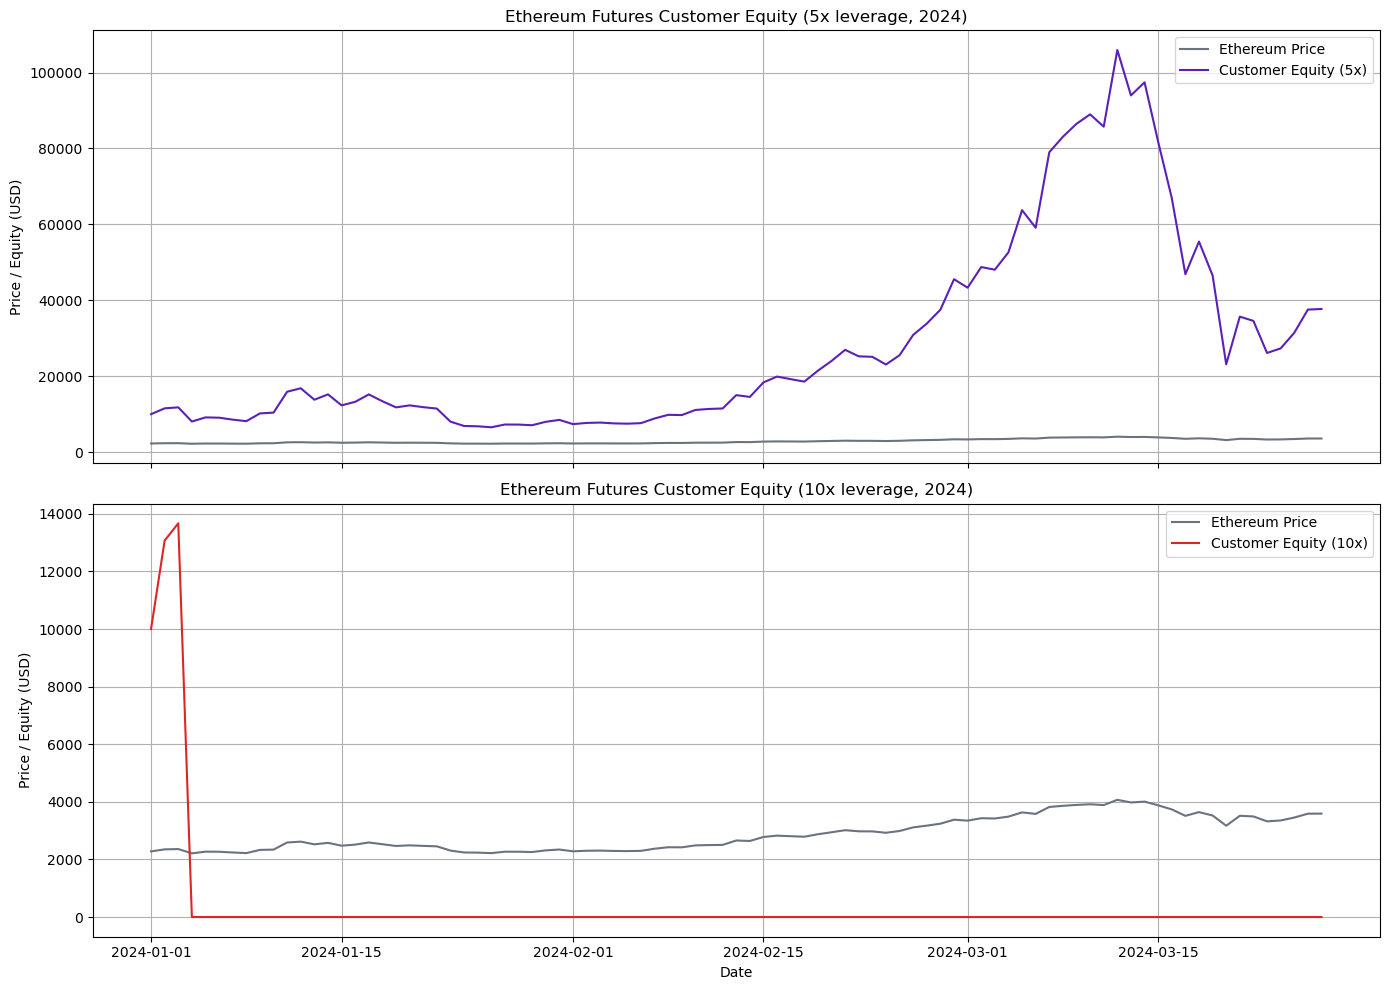

In [17]:
plot_single_coin_equity(eth_2024, "Ethereum", leverages=[5, 10])

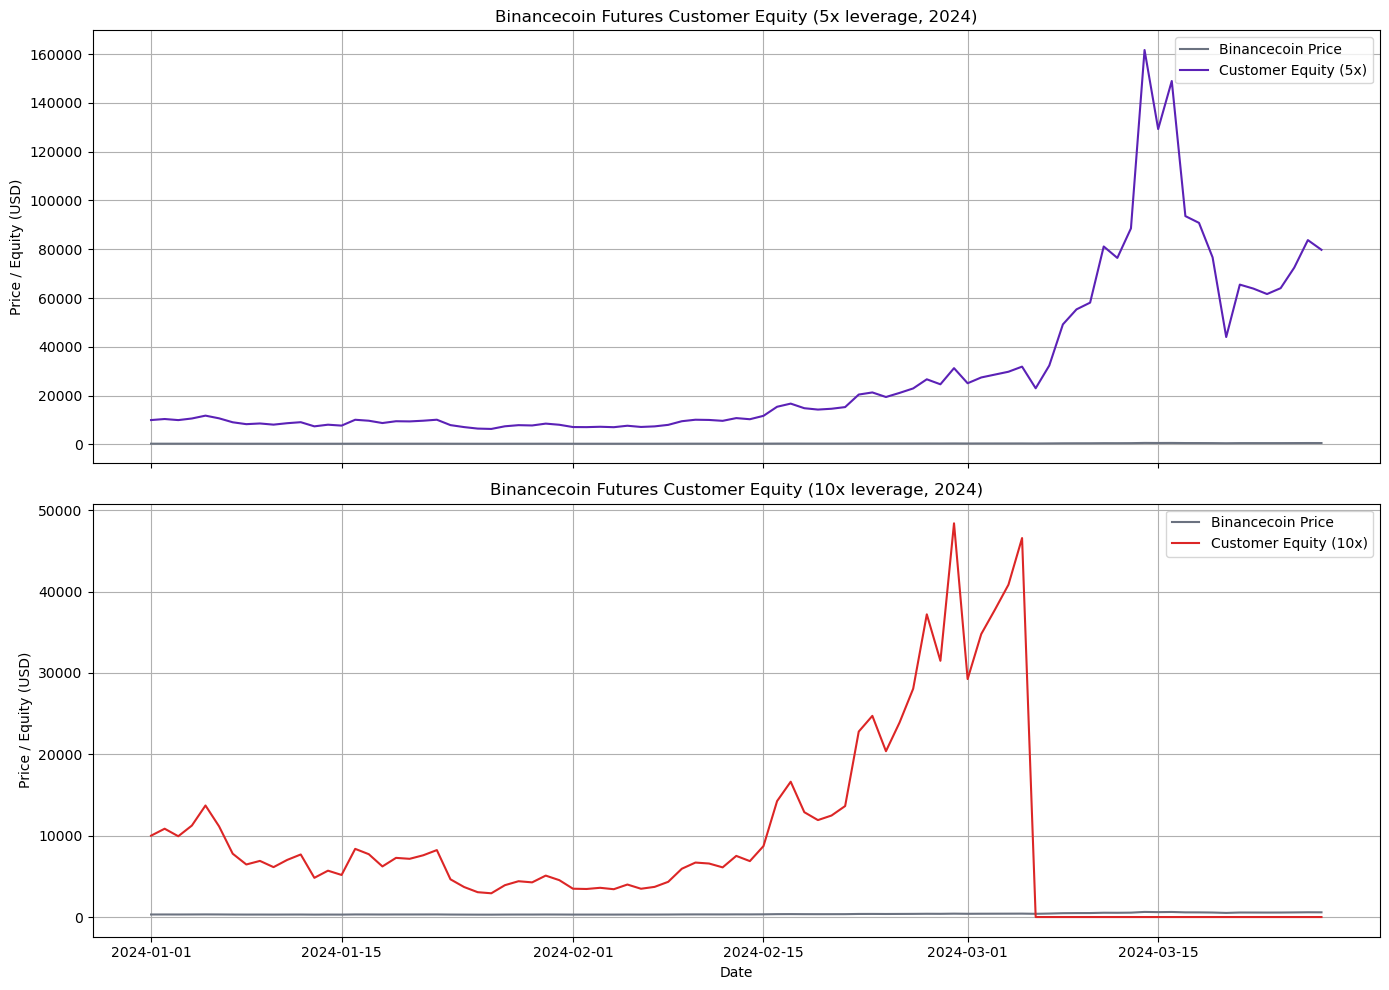

In [18]:
plot_single_coin_equity(binancecoin_2024, "Binancecoin", leverages=[5, 10])

## Impact of Leverage and Stop-Loss on Customer Equity and Exchange Profit

In this section, we simulate a leveraged futures trading environment offered by an exchange, focusing on three cryptocurrencies: BTC, ETH, and BNB. We apply 5x and 10x leverage to observe the effect of leverage on customer equity and exchange profit. The simulation accounts for daily price changes, initial opening fees, liquidation fees upon margin calls, and an optional stop-loss mechanism. This allows us to analyze how leverage and risk management strategies, such as stop-loss, impact both the customer’s potential gains/losses and the exchange’s profit.

In [19]:
def simulate_with_exchange(data, initial_equity, leverage, 
                           maintenance_margin_ratio=0.05,
                           fee_rate=0.001,             # 0.1%
                           liquidation_fee_rate=0.05,  # 5%
                           stop_loss_pct=None):        # stop-loss as % of initial equity
    
    equity = [initial_equity]
    liquidation = [False]
    exchange_profit = 0

    # Step 0: initial fee
    position_init = initial_equity * leverage
    fee = position_init * fee_rate
    exchange_profit += fee

    # Step 1: calculate stop-loss equity threshold
    stop_loss_equity = initial_equity * (1 - stop_loss_pct) if stop_loss_pct is not None else None

    for i in range(1, len(data)):
        daily_return = data['return'].iloc[i]
        position = equity[-1] * leverage
        pnl = position * daily_return
        new_equity = equity[-1] + pnl
        maintenance_margin = position * maintenance_margin_ratio

        # Step 2: Check Stop-Loss first 
        if stop_loss_equity is not None and new_equity <= stop_loss_equity:
            liquidation.append(True)
            liquidation_profit = equity[-1] * liquidation_fee_rate
            exchange_profit += liquidation_profit
            new_equity = max(new_equity, 0)
            # new_equity = 0

        # Step 3: Check Maintenance Margin 
        elif new_equity < maintenance_margin:
            liquidation.append(True)
            liquidation_profit = equity[-1] * liquidation_fee_rate
            exchange_profit += liquidation_profit
            new_equity = 0

        else:
            liquidation.append(False)

        equity.append(new_equity)

    return equity, liquidation, exchange_profit

In [20]:
def simulate_with_exchange(data, initial_equity, leverage, 
                           maintenance_margin_ratio=0.05,
                           fee_rate=0.001,             # 0.1%
                           liquidation_fee_rate=0.05,  # 5%
                           stop_loss_pct=None):        # stop-loss as % of initial equity
    
    equity = [initial_equity]
    liquidation = [False]
    exchange_profit = 0

    # Step 0: initial fee
    position_init = initial_equity * leverage
    fee = position_init * fee_rate
    exchange_profit += fee

    # Step 1: calculate stop-loss equity threshold
    stop_loss_equity = initial_equity * (1 - stop_loss_pct) if stop_loss_pct is not None else None

    # Step 2: iterate over daily returns
    active = True  # Is the client still active in the system?
    for i in range(1, len(data)):
        if not active:
            equity.append(equity[-1])   # keep the last number
            liquidation.append(False)
            continue
        #if not active, we do not have to caculate anymore

        daily_return = data['return'].iloc[i]
        position = equity[-1] * leverage
        pnl = position * daily_return
        new_equity = equity[-1] + pnl
        maintenance_margin = position * maintenance_margin_ratio

        # 2a: Stop-Loss check (protect customer)
        if stop_loss_equity is not None and new_equity <= stop_loss_equity:
            liquidation.append(True)
            
            liquidation_profit = equity[-1] * liquidation_fee_rate
            exchange_profit += liquidation_profit
            
            # add real equity in the list
            equity.append(max(new_equity, 0))
            active = False
            continue
            

        # 2b: Maintenance Margin check (forced liquidation)
        elif new_equity < maintenance_margin:
            liquidation.append(True)
            liquidation_profit = equity[-1] * liquidation_fee_rate
            exchange_profit += liquidation_profit
            new_equity = 0
            active = False  # Trading is over

        else:
            liquidation.append(False)

        equity.append(new_equity)

    return equity, liquidation, exchange_profit

In [21]:
# without stop-loss
btc_eq_5x, btc_liq_5x, btc_profit_5x = simulate_with_exchange(bitcoin_2024, 10000, 5)
btc_eq_10x, btc_liq_10x, btc_profit_10x = simulate_with_exchange(bitcoin_2024, 10000, 10)

print("Exchange Profit 5x without Stop-Loss:", btc_profit_5x)
print("Exchange Profit 10x without Stop-Loss:", btc_profit_10x)

# with stop-loss，eg. 5% 
btc_eq_5x_sl, btc_liq_5x_sl, btc_profit_5x_sl = simulate_with_exchange(bitcoin_2024, 10000, 5, stop_loss_pct=0.05)
btc_eq_10x_sl, btc_liq_10x_sl, btc_profit_10x_sl = simulate_with_exchange(bitcoin_2024, 10000, 10, stop_loss_pct=0.05)

print("Exchange Profit 5x with Stop-Loss:", btc_profit_5x_sl)
print("Exchange Profit 10x with Stop-Loss:", btc_profit_10x_sl)

Exchange Profit 5x without Stop-Loss: 50.0
Exchange Profit 10x without Stop-Loss: 900.586717676903
Exchange Profit 5x with Stop-Loss: 767.8950300337439
Exchange Profit 10x with Stop-Loss: 969.1741761244543


In [22]:
# ------------------------------
# Compute daily returns from equity
# ------------------------------
def compute_returns(equity):
    equity = np.array(equity)
    returns = np.diff(equity) / equity[:-1]
    returns = returns[~np.isnan(returns)]
    returns = returns[np.isfinite(returns)]
    return returns

# ------------------------------
# Max Drawdown
# ------------------------------
def max_drawdown(equity):
    equity = np.array(equity)
    peak = np.maximum.accumulate(equity)
    drawdown = (equity - peak) / peak
    return drawdown.min()

# ------------------------------
# Volatility (annualized)
# ------------------------------
def volatility(returns, trading_days=365):
    return np.std(returns) * np.sqrt(trading_days)

# ------------------------------
# Sharpe Ratio (assume risk-free = 0)
# ------------------------------
def sharpe_ratio(returns, trading_days=365):
    if np.std(returns) == 0:
        return 0
    return (np.mean(returns) / np.std(returns)) * np.sqrt(trading_days)

In [23]:
# ------------------------------
# Leverage levels to simulate
# ------------------------------
leverages = [2, 3, 5, 10, 20]

# ------------------------------
# Store results for each leverage
# ------------------------------
results = []

for lev in leverages:
    # Simulation without Stop-Loss
    # ------------------------------
    eq_no_sl, liq_no_sl, profit_no_sl = simulate_with_exchange(bitcoin_2024, initial_equity=10000, leverage=lev, stop_loss_pct=None)
    
    # Simulation with Stop-Loss at 10%
    eq_sl, liq_sl, profit_sl = simulate_with_exchange(bitcoin_2024, initial_equity=10000, leverage=lev, stop_loss_pct=0.1)

    # Calculate returns
    ret_no_sl = compute_returns(eq_no_sl)
    ret_sl = compute_returns(eq_sl)

    # Calculate maximum customer loss
    # ------------------------------
    max_loss_no_sl = 10000 - min(eq_no_sl)
    max_loss_sl = 10000 - min(eq_sl)
    

    # Record results for this leverage
    results.append({
        'Leverage': lev,

        # Max Drawdown
        'Max DD (No SL)': max_drawdown(eq_no_sl),
        'Max DD (SL)': max_drawdown(eq_sl),

        # Volatility
        'Vol (No SL)': volatility(ret_no_sl),
        'Vol (SL)': volatility(ret_sl),

        # Sharpe
        'Sharpe (No SL)': sharpe_ratio(ret_no_sl),
        'Sharpe (SL)': sharpe_ratio(ret_sl),

        'Leverage': lev,
        'Exchange Profit (No SL)': profit_no_sl,
        'Exchange Profit (SL)': profit_sl,
        'Max Customer Loss (No SL)': max_loss_no_sl,
        'Max Customer Loss (SL)': max_loss_sl
    })

C:\Users\vogel\AppData\Local\Temp\ipykernel_12556\3424912164.py:6: RuntimeWarning: invalid value encountered in divide
  returns = np.diff(equity) / equity[:-1]


In [24]:
# ------------------------------
# Convert results to DataFrame
# ------------------------------
df_results = pd.DataFrame(results)

### Plot Exchange Profit Comparison

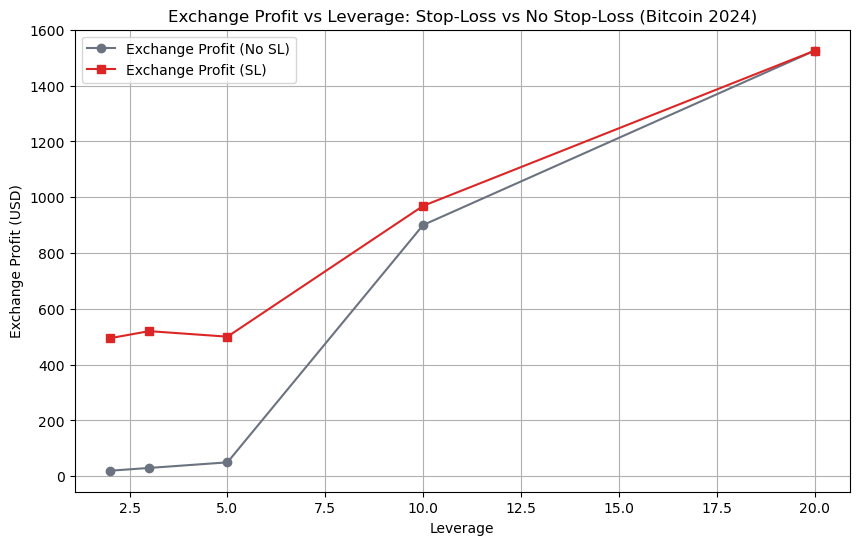

In [25]:
plt.figure(figsize=(10,6))
plt.plot(df_results['Leverage'], df_results['Exchange Profit (No SL)'], marker='o', label='Exchange Profit (No SL)', color='#6b7280')
plt.plot(df_results['Leverage'], df_results['Exchange Profit (SL)'], marker='s', label='Exchange Profit (SL)', color='#dc2626')
plt.title('Exchange Profit vs Leverage: Stop-Loss vs No Stop-Loss (Bitcoin 2024)')
plt.xlabel('Leverage')
plt.ylabel('Exchange Profit (USD)')
plt.grid(True)
plt.legend()
plt.show()

### Plot Maximum Customer Loss Comparison

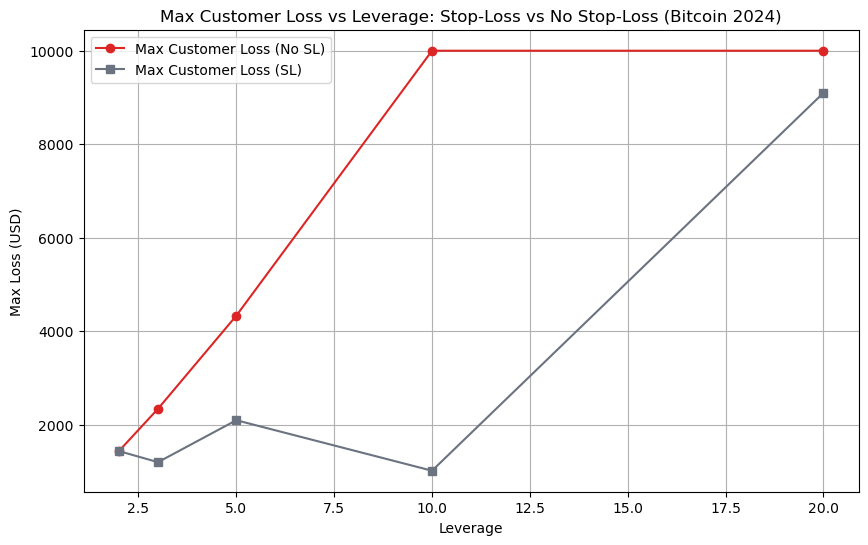

In [26]:
plt.figure(figsize=(10,6))
plt.plot(df_results['Leverage'], df_results['Max Customer Loss (No SL)'], marker='o',label='Max Customer Loss (No SL)',color='#dc2626')
plt.plot(df_results['Leverage'], df_results['Max Customer Loss (SL)'], marker='s', label='Max Customer Loss (SL)', color='#6b7280')
plt.title('Max Customer Loss vs Leverage: Stop-Loss vs No Stop-Loss (Bitcoin 2024)')
plt.xlabel('Leverage')
plt.ylabel('Max Loss (USD)')
plt.grid(True)
plt.legend()
plt.show()

### Plot Customer Equity vs Exchange Profit

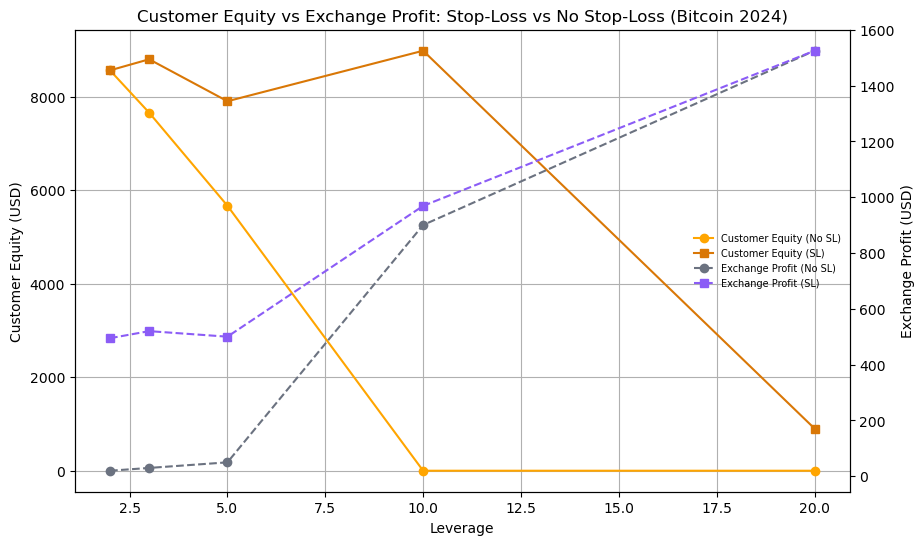

In [27]:
plt.figure(figsize=(10,6))

# Customer Equity curves (left y-axis)
l1, = plt.plot(df_results['Leverage'], 10000 - df_results['Max Customer Loss (No SL)'],
               marker='o', label='Customer Equity (No SL)', color='orange')
l2, = plt.plot(df_results['Leverage'], 10000 - df_results['Max Customer Loss (SL)'],
               marker='s', label='Customer Equity (SL)', color='#d97706')
plt.xlabel('Leverage')
plt.ylabel('Customer Equity (USD)')
plt.grid(True)

# Exchange Profit curves (right y-axis)
ax2 = plt.gca().twinx()
l3, = ax2.plot(df_results['Leverage'], df_results['Exchange Profit (No SL)'],
               marker='o', linestyle='--', label='Exchange Profit (No SL)', color='#6b7280')
l4, = ax2.plot(df_results['Leverage'], df_results['Exchange Profit (SL)'],
               marker='s', linestyle='--', label='Exchange Profit (SL)', color='#8b5cf6')
ax2.set_ylabel('Exchange Profit (USD)')

# Combine legends manually
plt.legend(handles=[l1, l2, l3, l4], loc='center right', fontsize = 7, frameon=False)

plt.title('Customer Equity vs Exchange Profit: Stop-Loss vs No Stop-Loss (Bitcoin 2024)')
plt.show()

Stop-loss mechanisms significantly reduce customer losses under moderate leverage, 
while simultaneously increasing exchange profitability by prolonging trading activity 
and generating additional fees.

However, under extreme leverage, stop-loss becomes less effective as margin liquidation 
can be triggered before stop-loss thresholds are reached.

### Risk Metrics

#### Max Draw Down

In [28]:
df_results.iloc[:, 0:3] 

,Leverage,Max DD (No SL),Max DD (SL)
0,2,-0.300109,-0.300109
1,3,-0.425907,-0.340283
2,5,-0.632406,-0.487438
3,10,-1.000000,-0.482972
4,20,-1.000000,-0.965943


SL significantly reduces drawdown at moderate leverage (3–10x).
At very high leverage (20x), SL still helps but cannot fully prevent huge loss because price moves exceed SL.
No SL → 10x+ leverage → full liquidation (-1.0).

#### Volatility

In [29]:
df_results[['Leverage', 'Vol (No SL)', 'Vol (SL)']]

,Leverage,Vol (No SL),Vol (SL)
0,2,1.214692,0.604087
1,3,1.822038,0.853077
2,5,3.036730,1.353638
3,10,8.033171,1.432715
4,20,15.490553,2.865431


#### Sharpe Ratio (Sharpe)

In [30]:
df_results[['Leverage', 'Sharpe (No SL)', 'Sharpe (SL)']]

,Leverage,Sharpe (No SL),Sharpe (SL)
0,2,3.855416,-0.777634
1,3,3.855416,-0.195727
2,5,3.855416,-0.016077
3,10,-0.063076,0.499199
4,20,2.379632,0.499199


Interesting pattern:
No SL → Sharpe looks high at low leverage because the equity curve hasn’t hit full liquidation yet (returns not normalized).
SL → Sharpe stabilizes at 0.5 at high leverage, reflecting more realistic risk-adjusted return.
This is a consequence of stopping trading when SL triggers: daily returns after SL = 0, which lowers volatility and gives positive Sharpe.

#### Exchange Profit & Max Customer Loss

In [31]:
df_results[['Leverage', 'Exchange Profit (No SL)', 'Exchange Profit (SL)', 
            'Max Customer Loss (No SL)','Max Customer Loss (SL)']]

,Leverage,Exchange Profit (No SL),Exchange Profit (SL),Max Customer Loss (No SL),Max Customer Loss (SL)
0,2,20.000000,494.964648,1432.376946,1432.376946
1,3,30.000000,520.244234,2338.090274,1195.346594
2,5,50.000000,500.404503,4329.378402,2093.040140
3,10,900.586718,969.174176,10000.000000,1012.245072
4,20,1525.209811,1525.209811,10000.000000,9097.351111


SL → platform profit increases at moderate leverage.
SL → customer maximum loss decreases dramatically for 3–10x.
At extreme leverage (20x), SL still limits customer loss but platform profit almost unchanged (customers already near liquidation).

Key Notes:
Stop-Loss protects customers by locking losses before margin hit.
Platform benefits: SL increases exchange profit due to liquidation fees on customers’ preemptive exit.
Risk Metrics align: Drawdown and volatility drop with SL Sharpe ratio becomes more realistic
High leverage caution: even SL cannot fully prevent massive loss at 20x.

Stop-loss not only reduces downside risk (drawdown),
but also improves risk-adjusted returns (Sharpe ratio), especially under moderate leverage.

## Multi-Customer & Multi-Coin Diversified Futures Simulation

In this section, we simulate a diversified portfolio of futures positions across multiple cryptocurrencies (BTC, ETH, BNB) for several customers. Each customer has a randomly assigned initial equity, leverage, and allocation across the three coins.

We calculate daily equity and liquidation events using leveraged returns for each coin, taking into account a maintenance margin requirement. This allows us to observe the effects of diversification, leverage, and allocation on customer outcomes, highlighting how different strategies and risk exposures impact equity trajectories over 2024.

In [32]:
# ------------------------------
# Multi-customer & multi-coin simulation
# ------------------------------
num_customers = 5
np.random.seed(42)  # reproducibility

# Generate random customer parameters
customers = []
for i in range(num_customers):
    customer = {
        'initial_equity': np.random.choice([5000, 10000, 20000]),
        'leverage': np.random.choice([5, 10]),
        # Random allocation across BTC, ETH, BNB
        'allocation': np.random.dirichlet(np.ones(3), size=1)[0]}
    customers.append(customer)

In [33]:
# Function to simulate daily equity and liquidation
def simulate_multi_equity(initial_equity, leverage, allocation, btc_ret, eth_ret, bnb_ret, maint_margin_ratio=0.05):
    equity = [initial_equity]
    liquidation = [False]
    
    for i in range(1, len(btc_ret)):
        daily_pnl = (equity[-1]*leverage*allocation[0]*btc_ret[i] +
                     equity[-1]*leverage*allocation[1]*eth_ret[i] +
                     equity[-1]*leverage*allocation[2]*bnb_ret[i])
        
        new_equity = equity[-1] + daily_pnl
        position = equity[-1] * leverage
        maintenance_margin = position * maint_margin_ratio
        
        if new_equity < maintenance_margin:
            liquidation.append(True)
            new_equity = 0
        else:
            liquidation.append(False)
        
        equity.append(new_equity)
    
    return equity, liquidation

In [34]:
# Simulate each customer
results = []
for idx, c in enumerate(customers):
    eq, liq = simulate_multi_equity(c['initial_equity'], c['leverage'], c['allocation'],
                                    bitcoin_2024['return'].values, 
                                    eth_2024['return'].values, 
                                    binancecoin_2024['return'].values)
    results.append({'equity': eq, 'liquidation': liq, 'customer': idx})

### Plot the Deversified Investment Profit in Crypto

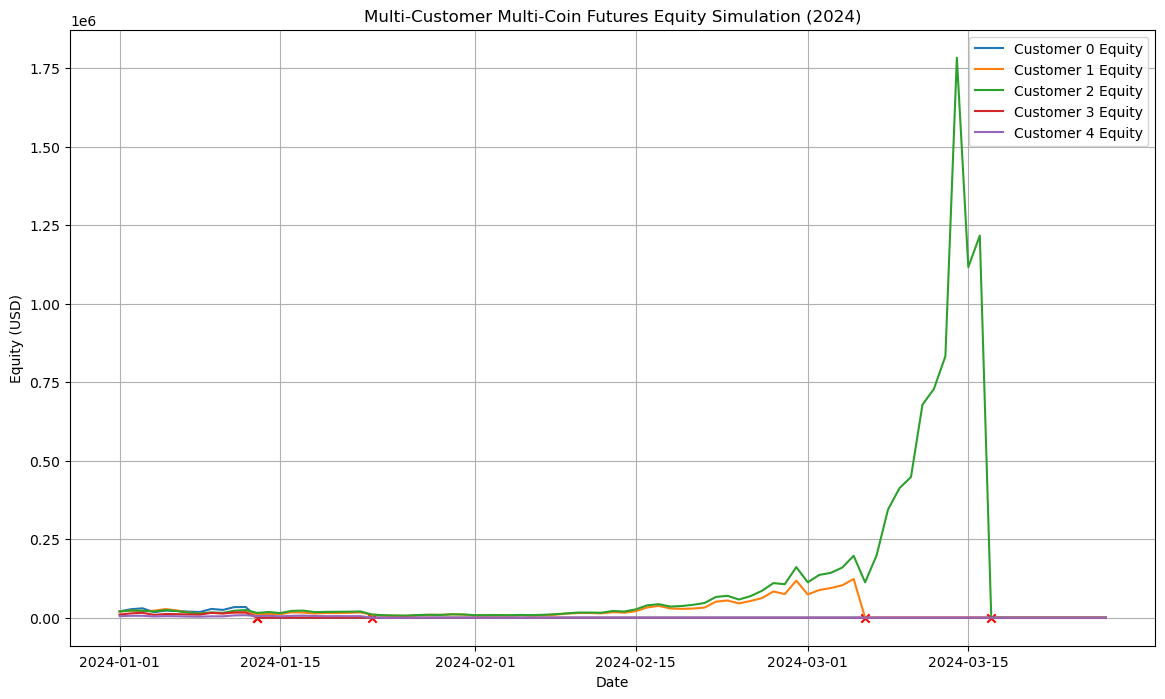

In [35]:
plt.figure(figsize=(14,8))
for r in results:
    plt.plot(dates, r['equity'], label=f"Customer {r['customer']} Equity")
    plt.scatter(dates[r['liquidation']], np.array(r['equity'])[r['liquidation']],
                color='red', marker='x')

plt.title('Multi-Customer Multi-Coin Futures Equity Simulation (2024)')
plt.xlabel('Date')
plt.ylabel('Equity (USD)')
plt.legend()
plt.grid(True)
plt.show()

The figure shows daily equity trajectories for multiple customers trading a diversified futures portfolio across BTC, ETH, and BNB in 2024. Each customer has different initial equity, leverage, and allocation across the three coins. Red crosses indicate liquidation events. This visualization highlights how diversification and leverage impact the risk and potential losses for individual traders.

### Plot Each Customer Separately

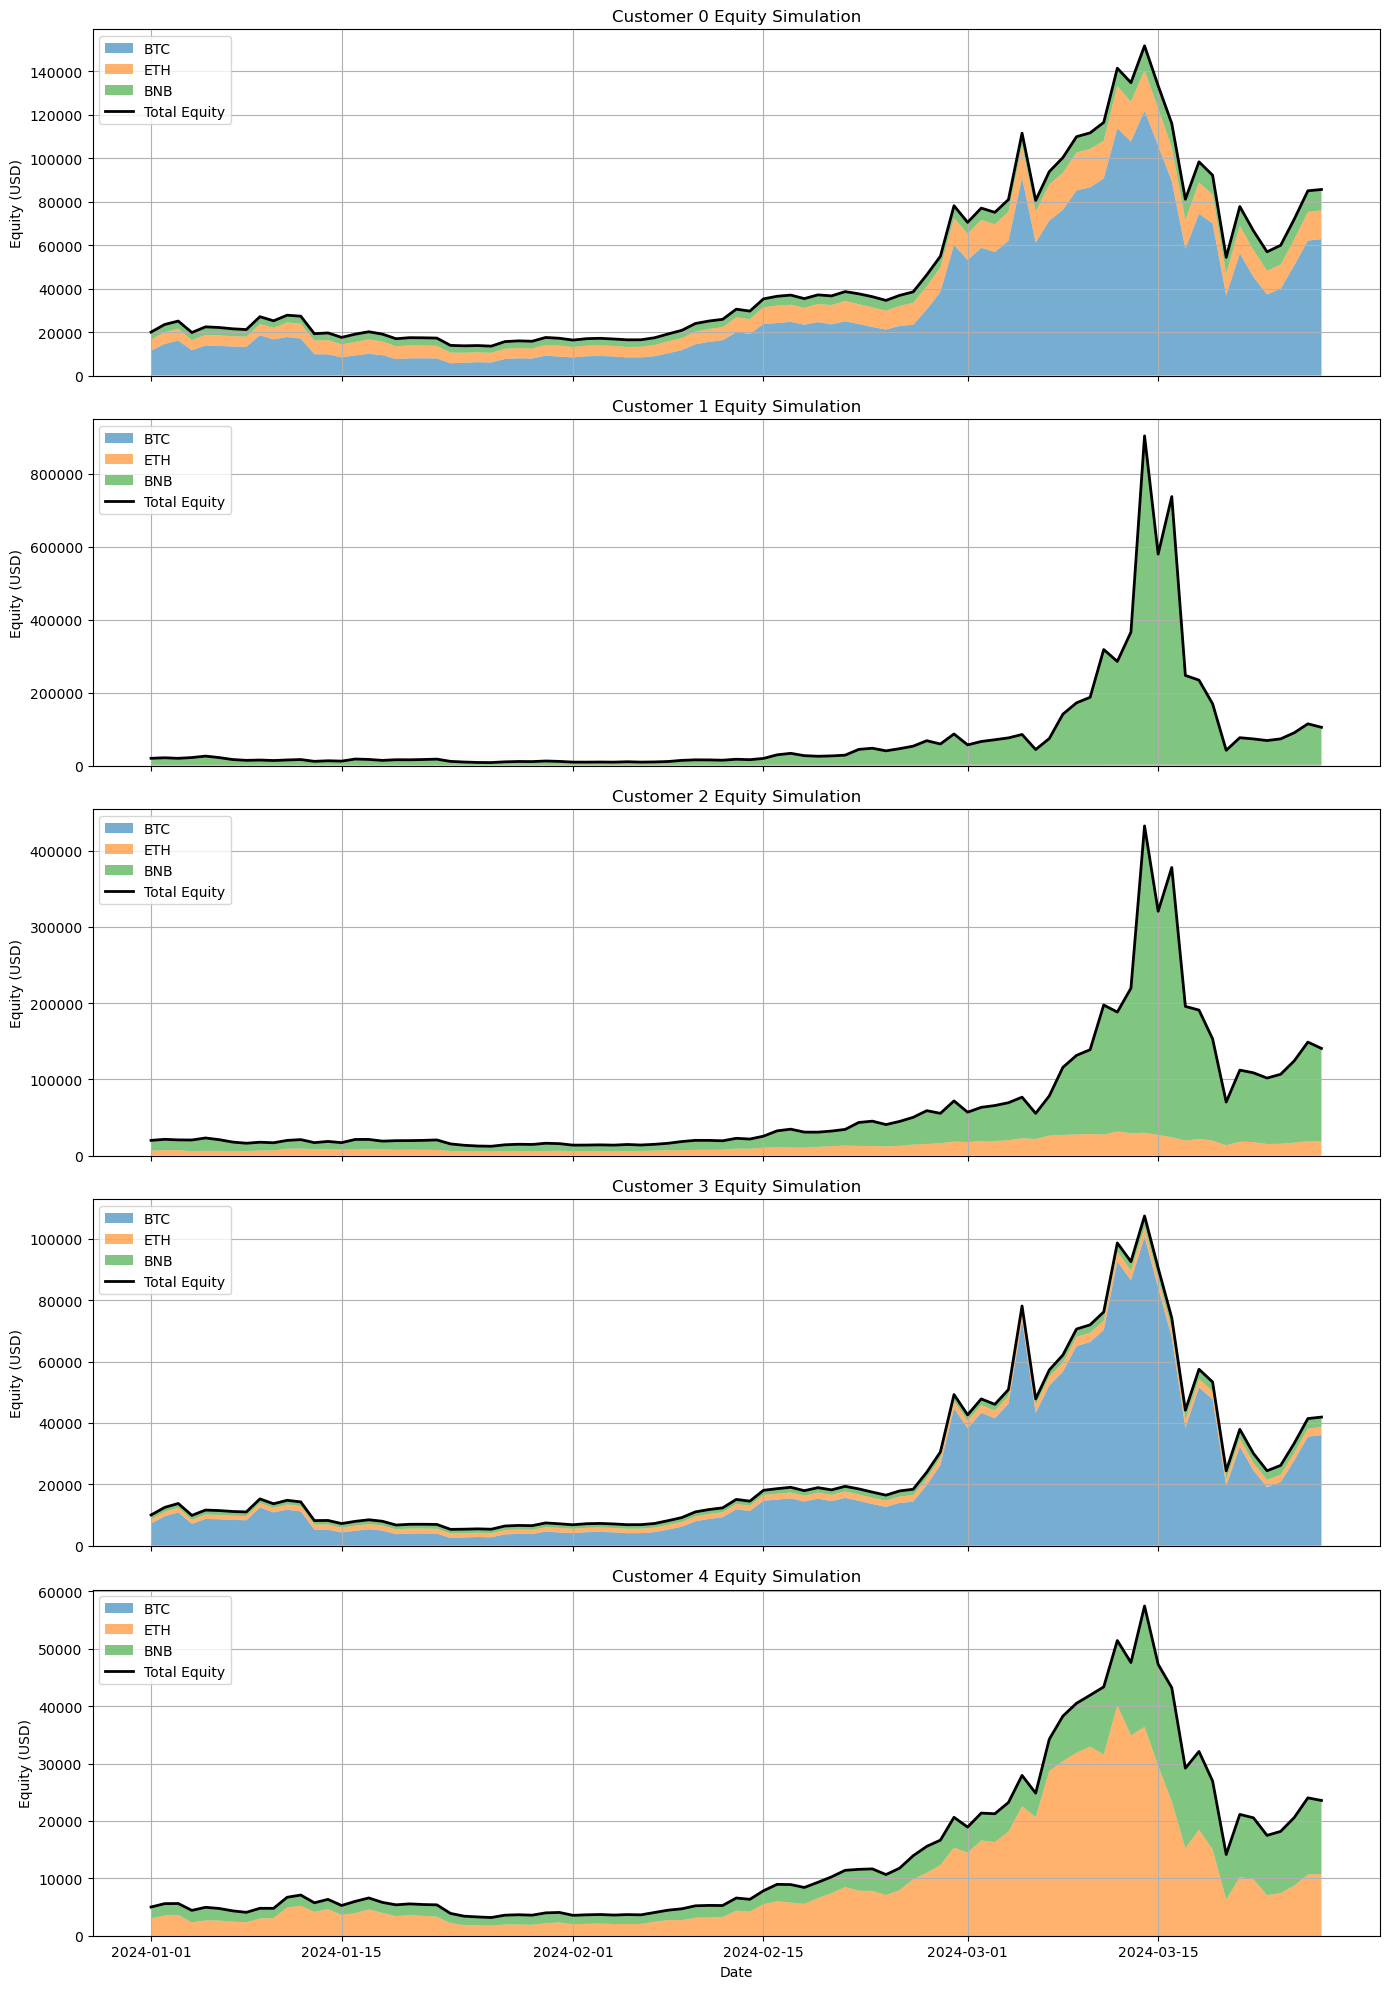

In [36]:
num_customers = len(customers)
fig, axes = plt.subplots(num_customers, 1, figsize=(14, 4*num_customers), sharex=True)

for idx, c in enumerate(customers):
    # Equity per coin
    btc_eq = [c['initial_equity'] * c['allocation'][0]]
    eth_eq = [c['initial_equity'] * c['allocation'][1]]
    bnb_eq = [c['initial_equity'] * c['allocation'][2]]
    
    for i in range(1, len(bitcoin_2024)):
        btc_daily = btc_eq[-1] + btc_eq[-1]*c['leverage']*c['allocation'][0]*bitcoin_2024['return'].iloc[i]
        eth_daily = eth_eq[-1] + eth_eq[-1]*c['leverage']*c['allocation'][1]*eth_2024['return'].iloc[i]
        bnb_daily = bnb_eq[-1] + bnb_eq[-1]*c['leverage']*c['allocation'][2]*binancecoin_2024['return'].iloc[i]
        
        btc_eq.append(max(btc_daily,0))
        eth_eq.append(max(eth_daily,0))
        bnb_eq.append(max(bnb_daily,0))
    
    total_eq = np.array(btc_eq) + np.array(eth_eq) + np.array(bnb_eq)
    
    axes[idx].stackplot(bitcoin_2024['date'], btc_eq, eth_eq, bnb_eq,
                        labels=['BTC','ETH','BNB'], alpha=0.6)
    
    # Plot total equity line
    axes[idx].plot(bitcoin_2024['date'], total_eq, color='black', label='Total Equity', linewidth=2)
    
    # Mark liquidation points
    liquid_idx = np.where(total_eq<=0)[0]
    if len(liquid_idx)>0:
        axes[idx].scatter(bitcoin_2024['date'].iloc[liquid_idx], total_eq[liquid_idx],
                          color='red', marker='x', s=50, label='Liquidation')
    
    axes[idx].set_title(f'Customer {idx} Equity Simulation')
    axes[idx].set_ylabel('Equity (USD)')
    axes[idx].grid(True)
    axes[idx].legend(loc='upper left')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

Each subplot shows the equity evolution for a single customer trading a diversified futures portfolio in 2024. Colored areas represent the contribution from BTC, ETH, and BNB, while the black line shows total equity. Red crosses indicate liquidation events. This visualization helps understand how allocation, leverage, and individual coin volatility affect each customer's risk and total portfolio performance.